Coded: 14/9/2026

## **Heston Model SDE**

### **1993: Stochastic volatility model by Heston**
The Heston model is a useful model for simulating stochastic volatility and its effect on the potential paths an asset can take over the life of an option.

- Popular because of easy closed-form solution for European option pricing
- no risk of negative variances
- incorporation of leverage effect
This allows for more effective modeling than the Black-Scholes formula allows due to its restrictive assumption of constant volatility.

### **Heston Model SDE**
The heston model is defined by a system of SDEs, to describe the movement of asset prices, where an asset’s price and volatility follow random, Brownian motion processes (this is under real world measure 
):


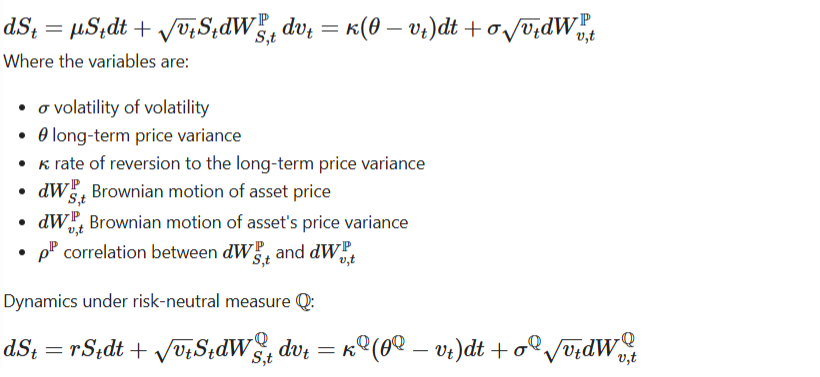

### **Heston Model for Monte Carlo Simulations**
Obviously as discussed one of the nice things about the Heston model for European option prices is that there is a closed-form solution once you have the characteristic function. So discretisation of the SDE is not required for valuing a European option, however if you would like to value other option types with complex features using the Heston model than you can use the following code:

### **Euler Discretisation of SDEs**
Great resource for explanation here: Euler and Milstein Discretization by Fabrice Douglas Rouah https://frouah.com/finance%20notes/Euler%20and%20Milstein%20Discretization.pdf

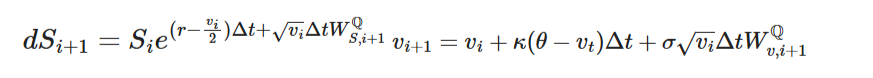

The Heston model is a useful model for simulating stochastic volatility and its effect on the potential paths an asset can take over the life of an option. It's popular because of:
- easy closed-form solution for European option pricing
- no risk of negative variances 
- incorporation of leverage effect
This allows for more effective modeling than the Black-Scholes formula allows due to its restrictive assumption of constant volatility.

One of the nice things about the Heston model for European option prices is that there is a closed-form solution once you have the characteristic function. So, discretisation of the SDE is not required for valuing a European option, however if you would like to value other option types with complex features using the Heston model than you can use the following code.

In [ ]:
# !pip install py_vollib_vectorized

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------- ------------------------- 1.0/2.8 MB 7.2 MB/s eta 0:00:01
   --------------------------------- ------ 2.4/2.8 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 6.5 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/41.9 MB 6.7 MB/s eta 0:00:07
   -- ------------------------------------- 2.9/41.9 MB 7.0 MB/s eta 0:00:06
   ---- ----------------------------------- 4.2/41.9 MB 7.0 MB/s eta 0:00:06
   ----- ---------------------------------- 6.0/41.9 MB 7.4 MB/s eta 0:00:05
   ------- -------------------------------- 8.1/41.9 MB 7.7 MB/s eta 0:00:05
   --------- ------------------------------ 10.0/41.9 MB 8.0 MB/s eta 0:00:05
   ----------- ---------------------------- 11.8/41.9 MB 8.1 MB/s eta 0:00:04
   ------------- 

#### **Import Dependencies**

In [4]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from py_vollib_vectorized import vectorized_implied_volatility as implied_vol

#### **Define Parameters**

Here we just define the parameters of the model under risk-neutral dynamics.

In [5]:
# Parameters
# simulation dependent

S0 = 100.0 # asset price
T = 1.0 # time in years
r = 0.02 # risk-free rate 
N = 252 # number of time steps in simulation (trading days)
M = 100000 # number of simulations

# Heston dependent parameters
kappa = 3 # rate of mean reversion of variance under risk-neutral dynamics
theta = 0.20**2 # long-term mean of variance under risk-neutral dynamics
v0 = 0.25**2 # initial variance under risk-neutral dynamics
rho = 0.7 # correlation between returns and variances under risk-neutral dynamics
sigma = 0.6  # volatitility of volatility

theta, v0

(0.04000000000000001, 0.0625)

#### **Monte Carlo Simulation**

Because we have a recursive function, we have to step through time within our simulation. However we can simulate the Brownian motions of the asset and variances outside of the for loop.

In [8]:
def heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M):
    """
    Inputs:
     - S0, v0: initial parameters for asset and variance
     - rho   : correlation between asset returns and variance
     - kappa : rate of mean reversion in variance process
     - theta : long-term mean of variance process
     - sigma : vol of vol / volatility of variance process
     - T     : time of simulation
     - N     : number of time steps
     - M     : number of scenarios / simulations

    Outputs:
    - asset prices over time (numpy array)
    - variance over time (numpy array)
    """
    # initialise other parameters
    dt = T/N
    mu = np.array([0,0])
    cov = np.array([[1,rho],
                    [rho,1]])

    # arrays for storing prices and variances
    S = np.full(shape=(N+1,M), fill_value=S0)
    v = np.full(shape=(N+1,M), fill_value=v0)

    # sampling correlated brownian motions under risk-neutral measure
    Z = np.random.multivariate_normal(mu, cov, (N,M))

    for i in range(1,N+1):
        S[i] = S[i-1] * np.exp( (r - 0.5*v[i-1])*dt + np.sqrt(v[i-1] * dt) * Z[i-1,:,0] )
        v[i] = np.maximum(v[i-1] + kappa*(theta-v[i-1])*dt + sigma*np.sqrt(v[i-1]*dt)*Z[i-1,:,1],0)

    return S, v

In [9]:
rho_p = 0.98
rho_n = -0.98

S_p,v_p = heston_model_sim(S0, v0, rho_p, kappa, theta, sigma,T, N, M)
S_n,v_n = heston_model_sim(S0, v0, rho_n, kappa, theta, sigma,T, N, M)

#### **Plotting the asset prices and variance over time**

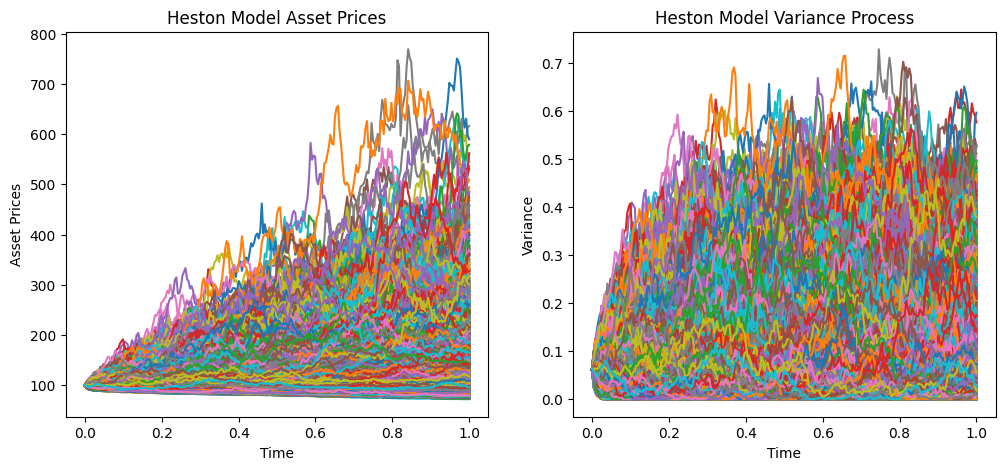

In [10]:
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(12,5))
time = np.linspace(0,T,N+1)
ax1.plot(time,S_p)
ax1.set_title('Heston Model Asset Prices')
ax1.set_xlabel('Time')
ax1.set_ylabel('Asset Prices')

ax2.plot(time,v_p)
ax2.set_title('Heston Model Variance Process')
ax2.set_xlabel('Time')
ax2.set_ylabel('Variance')

plt.show()

#### **Asset price distribution with different correlations**

In [11]:
# simulate gbm process at time T
gbm = S0*np.exp( (r - theta**2/2)*T + np.sqrt(theta)*np.sqrt(T)*np.random.normal(0,1,M) )

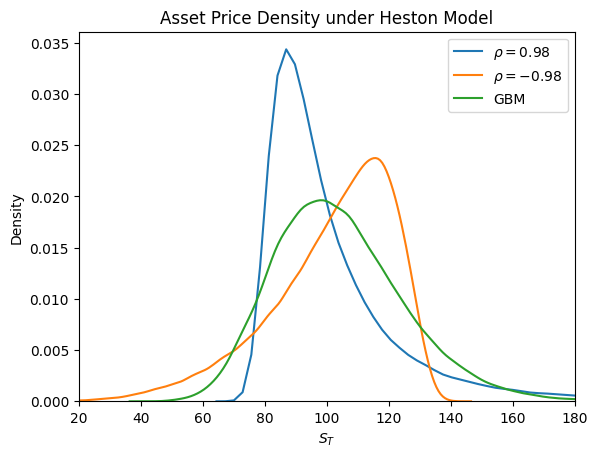

In [12]:
fig, ax = plt.subplots()

ax = sns.kdeplot(S_p[-1], label=r"$\rho= 0.98$", ax=ax)
ax = sns.kdeplot(S_n[-1], label=r"$\rho= -0.98$", ax=ax)
ax = sns.kdeplot(gbm, label="GBM", ax=ax)

plt.title(r'Asset Price Density under Heston Model')
plt.xlim([20, 180])
plt.xlabel('$S_T$')
plt.ylabel('Density')
plt.legend()
plt.show()

#### **Capturing the Volatililty Smile in Option Pricing**

In [13]:
rho = -0.7
S,v = heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M)

In [16]:
# # Set strikes and complete MC option price for different strikes
# K = np.arange(20,180,2)

# puts = np.array([np.exp(-r*T)*np.mean(np.maximum(k-S,0)) for k in K])
# calls = np.array([np.exp(-r*T)*np.mean(np.maximum(S-k,0)) for k in K])

# put_ivs = implied_vol(puts, S0, K, T, r, flag='p', q=0, return_as='numpy', on_error='ignore')
# call_ivs = implied_vol(calls, S0, K, T, r, flag='c', q=0, return_as='numpy')

In [17]:
from py_vollib.black_scholes_merton.implied_volatility import implied_volatility

# Set strikes and complete MC option price for different strikes
K = np.arange(20, 180, 2)

puts = np.array([np.exp(-r*T)*np.mean(np.maximum(k-S[-1], 0)) for k in K])
calls = np.array([np.exp(-r*T)*np.mean(np.maximum(S[-1]-k, 0)) for k in K])

# Use a list comprehension to call the non-vectorized function
put_ivs = np.array([implied_volatility(p, S0, k, T, r, 'p') for p, k in zip(puts, K)])
call_ivs = np.array([implied_volatility(c, S0, k, T, r, 'c') for c, k in zip(calls, K)])

# Note: We also corrected S to S[-1] for the payoff, as S is a path matrix (N+1, M).
# The option payoff depends only on the price at maturity (S_T), not the entire path.

ValueError: Data type <class 'numpy.int64'> unsupported, must be in: list, tuple, np.array, pd.Series.

In [ ]:
plt.plot(K, call_ivs, label=r'IV calls')
plt.plot(K, put_ivs, label=r'IV puts')

plt.ylabel('Implied Volatility')
plt.xlabel('Strike')

plt.title('Implied Volatility Smile from Heston Model')
plt.legend()
plt.show()